# Data Preprocessing

## Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
features = pd.read_csv('/content/features.csv')

In [ ]:
stores = pd.read_csv('/content/stores.csv')

In [ ]:
test = pd.read_csv('/content/test.csv')

In [ ]:
train = pd.read_csv('/content/train.csv')

## Data Cleaning

In [ ]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [ ]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


**We will group the datasets on weekly indicators to remove the missing values. Also it can help in the following**
1. Our other dataset also has data aggregated weekly (e.g., sales data).
2. We are not interested in day-level granularity.
3. We are working on a time series, trend analysis, or forecasting at the weekly level.

**To change the datatype of the Date column to datetime and extract the month into a new column**

In [ ]:
# Convert 'Date' column to datetime
features['Date'] = pd.to_datetime(features['Date'])

In [ ]:
# Create additional date-based columns
features['Week'] = features['Date'].dt.isocalendar().week  # ISO week number
features['Month'] = features['Date'].dt.month_name()
features['Year'] = features['Date'].dt.year

In [ ]:
# Step 2: Group by Year, Month, and Week
weekly_avg = features.groupby(['Year', 'Month', 'Week'])[
    ['Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
     'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']
].mean().reset_index()

In [ ]:
weekly_avg.describe()

,Year,Week,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,182.000000,182.0,182.000000,182.000000,90.000000,83.000000,90.000000,90.000000,90.000000,169.000000,169.000000
mean,2011.351648,25.214286,59.356198,3.405992,7031.733056,2694.596974,1683.031146,3161.221928,4132.216422,172.460809,7.826821
std,1.044572,14.566791,15.293793,0.395918,6584.708048,6300.642802,9669.039751,4994.635546,2878.504519,3.530685,0.602577
min,2010.000000,1.0,30.480889,2.672067,556.328636,2.858182,0.128929,70.310286,1449.486889,167.546485,6.719244
25%,2010.000000,13.0,45.893333,3.009417,3902.696367,118.515974,20.616224,671.571333,2637.415333,168.522268,7.237333
50%,2011.000000,24.0,59.158333,3.539222,5526.103487,325.355135,63.814492,1777.919855,3386.596444,172.202844,8.097489
75%,2012.000000,37.0,73.538889,3.716544,8162.312833,1982.613504,186.326392,3152.826538,4901.583722,175.648168,8.428578
max,2013.000000,52.0,82.176444,3.997778,49002.610889,39351.596444,70130.239545,29920.769302,21940.824444,177.990680,8.619311


In [ ]:
weekly_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          182 non-null    int32  
 1   Month         182 non-null    object 
 2   Week          182 non-null    UInt32 
 3   Temperature   182 non-null    float64
 4   Fuel_Price    182 non-null    float64
 5   MarkDown1     90 non-null     float64
 6   MarkDown2     83 non-null     float64
 7   MarkDown3     90 non-null     float64
 8   MarkDown4     90 non-null     float64
 9   MarkDown5     90 non-null     float64
 10  CPI           169 non-null    float64
 11  Unemployment  169 non-null    float64
dtypes: UInt32(1), float64(9), int32(1), object(1)
memory usage: 15.9+ KB


**To impute missing values in the MarkDown columns (and optionally CPI and Unemployment), we can choose techniques that respect the temporal nature of the data and the fact that the data is not missing completely at random, especially since:**

* MarkDown data is only available after Nov 2011.
* It is not consistently reported across stores or time.

**We will follow the following steps**
* Identifies pre- vs. post-Nov 2011.
* Pre-Nov 2011: Fills all markdown columns with 0.
* Post-Nov 2011: First fills missing values using weekly average, then uses linear interpolation for any remaining missing values.

In [ ]:
# Step 1: Create a datetime reference column to compare with Nov 2011
weekly_avg['Ref_Date'] = pd.to_datetime(weekly_avg['Year'].astype(str) + '-' + weekly_avg['Month'] + '-1')

In [ ]:
# Step 2: List of MarkDown columns
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

In [ ]:
# Step 3: Separate pre-Nov 2011 and post-Nov 2011 data
cutoff_date = pd.to_datetime('2011-11-01')
pre_nov = weekly_avg['Ref_Date'] < cutoff_date
post_nov = weekly_avg['Ref_Date'] >= cutoff_date

In [ ]:
# Step 4: Fill pre-Nov 2011 MarkDowns with 0 (or keep as NA if preferred)
weekly_avg.loc[pre_nov, markdown_cols] = weekly_avg.loc[pre_nov, markdown_cols].fillna(0)

In [ ]:
# Step 5: Group-mean imputation for post-Nov 2011
for col in markdown_cols:
    # Fill NA with monthly group mean
    weekly_avg.loc[post_nov, col] = (
        weekly_avg.loc[post_nov]
        .groupby(['Year', 'Month'])[col]
        .transform(lambda x: x.fillna(x.mean()))
    )

In [ ]:
# Step 6: Fallback for remaining missing values in post-Nov 2011 using interpolation
weekly_avg.loc[post_nov, markdown_cols] = (
    weekly_avg.loc[post_nov, markdown_cols].interpolate(method='linear')
)

In [ ]:
# Step 7: Drop helper column if not needed
weekly_avg.drop(columns='Ref_Date', inplace=True)

In [ ]:
weekly_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          182 non-null    int32  
 1   Month         182 non-null    object 
 2   Week          182 non-null    UInt32 
 3   Temperature   182 non-null    float64
 4   Fuel_Price    182 non-null    float64
 5   MarkDown1     182 non-null    float64
 6   MarkDown2     182 non-null    float64
 7   MarkDown3     182 non-null    float64
 8   MarkDown4     182 non-null    float64
 9   MarkDown5     182 non-null    float64
 10  CPI           169 non-null    float64
 11  Unemployment  169 non-null    float64
dtypes: UInt32(1), float64(9), int32(1), object(1)
memory usage: 15.9+ KB


**To impute values in the CPI and Unemployment column, the imputation strategy should respect their macroeconomic nature, which typically changes slowly and steadily over time.**

**Recommended Strategy for CPI and Unemployment:**
* Group mean imputation by [Year, Month, Week] – to preserve monthly macro-level consistency.
* Forward/Backward fill – for smooth trends over time, especially for edge cases.
* Interpolation fallback – in case group stats or ffill aren't sufficient.

**Why this works:**
* These variables rarely change abruptly.
* Missing values likely come from unavailable records, not structural absence like the MarkDowns.
* Linear interpolation or fill-forward preserves overall trend without introducing bias.

In [ ]:
# List of macroeconomic columns
macro_cols = ['CPI', 'Unemployment']

In [ ]:
# Step 1: Group mean imputation by (Year, Month, Week)
for col in macro_cols:
    weekly_avg[col] = (
        weekly_avg
        .groupby(['Year', 'Month', 'Week'])[col]
        .transform(lambda x: x.fillna(x.mean()))
    )

In [ ]:
# Step 2: Forward fill for any remaining missing values
weekly_avg[macro_cols] = weekly_avg[macro_cols].fillna(method='ffill')

In [ ]:
# Step 3: Backward fill for leading NAs
weekly_avg[macro_cols] = weekly_avg[macro_cols].fillna(method='bfill')

In [ ]:
# Step 4: Interpolation as final fallback (in case some are still missing)
weekly_avg[macro_cols] = weekly_avg[macro_cols].interpolate(method='linear')

In [ ]:
weekly_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          182 non-null    int32  
 1   Month         182 non-null    object 
 2   Week          182 non-null    UInt32 
 3   Temperature   182 non-null    float64
 4   Fuel_Price    182 non-null    float64
 5   MarkDown1     182 non-null    float64
 6   MarkDown2     182 non-null    float64
 7   MarkDown3     182 non-null    float64
 8   MarkDown4     182 non-null    float64
 9   MarkDown5     182 non-null    float64
 10  CPI           182 non-null    float64
 11  Unemployment  182 non-null    float64
dtypes: UInt32(1), float64(9), int32(1), object(1)
memory usage: 15.9+ KB


In [ ]:
weekly_avg.describe()

,Year,Week,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,182.000000,182.0,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,2011.351648,25.214286,59.356198,3.405992,3508.891213,1387.763749,942.932844,1572.414235,2066.193269,172.823502,7.758937
std,1.044572,14.566791,15.293793,0.395918,5805.946446,4600.071233,6980.403263,3842.494133,2892.571486,3.646198,0.630284
min,2010.000000,1.0,30.480889,2.672067,0.000000,0.000000,0.000000,0.000000,0.000000,167.546485,6.719244
25%,2010.000000,13.0,45.893333,3.009417,0.000000,0.000000,0.000000,0.000000,0.000000,168.582724,7.237333
50%,2011.000000,24.0,59.158333,3.539222,278.164318,1.429091,0.064464,35.155143,724.743444,173.084948,7.804222
75%,2012.000000,37.0,73.538889,3.716544,5602.283676,305.698041,64.282960,1745.947067,3404.138667,176.086612,8.428578
max,2013.000000,52.0,82.176444,3.997778,49002.610889,39351.596444,70130.239545,29920.769302,21940.824444,177.990680,8.619311


In [ ]:
weekly_avg.head()

,Year,Month,Week,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,2010,April,13,53.120889,2.827333,0.0,0.0,0.0,0.0,0.0,167.789036,8.497711
1,2010,April,14,58.420667,2.853089,0.0,0.0,0.0,0.0,0.0,167.718340,8.497711
2,2010,April,15,58.021111,2.889000,0.0,0.0,0.0,0.0,0.0,167.663041,8.497711
3,2010,April,16,57.089556,2.881733,0.0,0.0,0.0,0.0,0.0,167.628269,8.497711
4,2010,April,17,57.854667,2.891533,0.0,0.0,0.0,0.0,0.0,167.593497,8.497711


**Let's work on the train dataset to merge it with the economic indicators which we have grouped in weekly_avg dataset.**

In [ ]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/10,24924.50,False
1,1,1,12/02/10,46039.49,True
2,1,1,19/02/10,41595.55,False
3,1,1,26/02/10,19403.54,False
4,1,1,05/03/10,21827.90,False


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [ ]:
# Step 1: Convert 'Date' column to datetime
train['Date'] = pd.to_datetime(train['Date'])

In [ ]:
# Step 2: Extract Week, Month (as name), and Year into new columns
train['Week'] = train['Date'].dt.isocalendar().week.astype('UInt32')  # ensure compatibility with weekly_avg
train['Month'] = train['Date'].dt.strftime('%B')  # Full month name
train['Year'] = train['Date'].dt.year

In [ ]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Week,Month,Year
0,1,1,2010-05-02,24924.50,False,17,May,2010
1,1,1,2010-12-02,46039.49,True,48,December,2010
2,1,1,2010-02-19,41595.55,False,7,February,2010
3,1,1,2010-02-26,19403.54,False,8,February,2010
4,1,1,2010-05-03,21827.90,False,18,May,2010


**Similarly, let's work on the test dataset to merge it with the economic indicators which we have grouped in weekly_avg dataset.**

In [ ]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB


In [ ]:
# Step 1: Convert 'Date' column to datetime
test['Date'] = pd.to_datetime(test['Date'])

In [ ]:
# Step 2: Extract Week, Month (as name), and Year into new columns
test['Week'] = test['Date'].dt.isocalendar().week.astype('UInt32')  # ensure compatibility with weekly_avg
test['Month'] = test['Date'].dt.strftime('%B')  # Full month name
test['Year'] = test['Date'].dt.year

In [ ]:
test.head()

,Store,Dept,Date,IsHoliday,Week,Month,Year
0,1,1,2012-11-02,False,44,November,2012
1,1,1,2012-11-09,False,45,November,2012
2,1,1,2012-11-16,False,46,November,2012
3,1,1,2012-11-23,True,47,November,2012
4,1,1,2012-11-30,False,48,November,2012


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Store      115064 non-null  int64         
 1   Dept       115064 non-null  int64         
 2   Date       115064 non-null  datetime64[ns]
 3   IsHoliday  115064 non-null  bool          
 4   Week       115064 non-null  UInt32        
 5   Month      115064 non-null  object        
 6   Year       115064 non-null  int32         
dtypes: UInt32(1), bool(1), datetime64[ns](1), int32(1), int64(2), object(1)
memory usage: 4.6+ MB


**Let's have a look at stores dataset before we move ahead.**

In [ ]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [ ]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


**Stores dataset looks good to move ahead.**

## Data Merging

**Merge train with weekly_avg on Year, Month, Week**

In [ ]:
train_merged = train.merge(
    weekly_avg,
    on=['Year', 'Month', 'Week'],
    how='left'  # Use left join to keep all train data, bring in matching weekly_avg data
)

In [ ]:
train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Week          421570 non-null  UInt32        
 6   Month         421570 non-null  object        
 7   Year          421570 non-null  int32         
 8   Temperature   415680 non-null  float64       
 9   Fuel_Price    415680 non-null  float64       
 10  MarkDown1     415680 non-null  float64       
 11  MarkDown2     415680 non-null  float64       
 12  MarkDown3     415680 non-null  float64       
 13  MarkDown4     415680 non-null  float64       
 14  MarkDown5     415680 non-null  float64       
 15  CPI           415

**Merge the result with stores on Store**

In [ ]:
final_df = train_merged.merge(
    stores,
    on='Store',
    how='left'  # Keep all records from train, add store info
)

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 421570 entries, 0 to 421569
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Week          421570 non-null  UInt32        
 6   Month         421570 non-null  object        
 7   Year          421570 non-null  int64         
 8   Temperature   415680 non-null  float64       
 9   Fuel_Price    415680 non-null  float64       
 10  MarkDown1     415680 non-null  float64       
 11  MarkDown2     415680 non-null  float64       
 12  MarkDown3     415680 non-null  float64       
 13  MarkDown4     415680 non-null  float64       
 14  MarkDown5     415680 non-null  float64       
 15  CPI           415

In [ ]:
final_df.to_csv('final_df.csv', index=False)

**Now that you have the merged final_df, and we are seeing missing values in the columns from weekly_avg, we can handle them systematically.**

**Strategy for Handling Missing Values in final_df**

These columns have missing values due to unmatched weeks/months during the merge: Temperature, Fuel_Price, MarkDown1–5, CPI, Unemployment
1. Interpolate temporally within each Store. This works well for time series data (like temperature, fuel price, etc.).
2. Forward/Backward Fill as Backup to fill any leading or trailing NaNs after interpolation.
3. Final Sanity Check: Fill Remaining NaNs with 0. This should only be necessary for MarkDown columns pre-Nov 2011, where promotions didn’t exist.
4. Verify Missing Values

In [ ]:
# Step 1:
final_df.sort_values(by=['Store', 'Date'], inplace=True)

cols_to_interpolate = [
    'Temperature', 'Fuel_Price',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment'
]

for col in cols_to_interpolate:
    final_df[col] = final_df.groupby('Store')[col].transform(lambda x: x.interpolate(method='linear'))

In [ ]:
# Step 2:  Forward/Backward Fill as Backup
final_df[cols_to_interpolate] = final_df[cols_to_interpolate].fillna(method='ffill')
final_df[cols_to_interpolate] = final_df[cols_to_interpolate].fillna(method='bfill')

In [ ]:
# Step 3: Fill Remaining NaNs with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
final_df[markdown_cols] = final_df[markdown_cols].fillna(0)

In [ ]:
# Step 4: Verify Missing Values
print(final_df[cols_to_interpolate].isnull().sum())

Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
dtype: int64


**Finally we have final_df (merged dataset) without any missing value.**

**Similarly, we will merge the test dataset with the stores and weekly_avg dataset.**

In [ ]:
final_df.to_csv('final_df.csv', index=False)

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 421570 entries, 34 to 421567
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Week          421570 non-null  UInt32        
 6   Month         421570 non-null  object        
 7   Year          421570 non-null  int32         
 8   Temperature   421570 non-null  float64       
 9   Fuel_Price    421570 non-null  float64       
 10  MarkDown1     421570 non-null  float64       
 11  MarkDown2     421570 non-null  float64       
 12  MarkDown3     421570 non-null  float64       
 13  MarkDown4     421570 non-null  float64       
 14  MarkDown5     421570 non-null  float64       
 15  CPI           421570 

In [ ]:
test_merged = test.merge(
    weekly_avg,
    on=['Year', 'Month', 'Week'],
    how='left'  # Use left join to keep all train data, bring in matching weekly_avg data
)

In [ ]:
test_df = test_merged.merge(
    stores,
    on='Store',
    how='left'  # Keep all records from train, add store info
)

In [ ]:
test_df.head()

,Store,Dept,Date,IsHoliday,Week,Month,Year,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,44,November,2012,54.615556,3.676289,8478.388182,6571.306222,37.750698,4520.292973,2918.492889,176.646352,6.953711,A,151315
1,1,1,2012-11-09,False,45,November,2012,52.718889,3.603111,7188.592000,5841.027556,52.863810,1652.804737,3295.318000,176.643222,6.953711,A,151315
2,1,1,2012-11-16,False,46,November,2012,47.114444,3.549289,10216.026222,877.146818,80.335116,1250.629737,21940.824444,176.655161,6.953711,A,151315
3,1,1,2012-11-23,True,47,November,2012,49.637778,3.526311,1236.118444,4.123333,70130.239545,481.782703,1449.486889,176.687192,6.953711,A,151315
4,1,1,2012-11-30,False,48,November,2012,45.773333,3.502067,2912.441778,2.858182,6338.556216,180.575000,6031.299556,176.719224,6.953711,A,151315


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 115064 entries, 0 to 115063
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         115064 non-null  int64         
 1   Dept          115064 non-null  int64         
 2   Date          115064 non-null  datetime64[ns]
 3   IsHoliday     115064 non-null  bool          
 4   Week          115064 non-null  UInt32        
 5   Month         115064 non-null  object        
 6   Year          115064 non-null  int64         
 7   Temperature   115064 non-null  float64       
 8   Fuel_Price    115064 non-null  float64       
 9   MarkDown1     115064 non-null  float64       
 10  MarkDown2     115064 non-null  float64       
 11  MarkDown3     115064 non-null  float64       
 12  MarkDown4     115064 non-null  float64       
 13  MarkDown5     115064 non-null  float64       
 14  CPI           115064 non-null  float64       
 15  Unemployment  115

**Finally we have two dataframes with merged datasets which we will work on.**
1. final_df: we will use for feature engineering, train, and evaluate the model.
2. test_df: we will use the best forecasting model to forecast the sales for this dataset. We will finally evaluate and select the best forecasting model.

## Outlier Detection

**Outliers are extreme values that differ significantly from other observations. These can distort model training, especially in forecasting tasks. We'll apply a few robust statistical techniques:**

#### Use IQR Method (Interquartile Range)

This is suitable for detecting outliers in non-normally distributed data like Weekly_Sales, MarkDowns, and possibly CPI, Unemployment.
* Q1 = 25th percentile
* Q3 = 75th percentile
* IQR = Q3 - Q1

In [ ]:
# Columns to check for outliers
cols_to_check = [
    'Weekly_Sales', 'Temperature', 'Fuel_Price',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment'
]

# Store outlier index info
outlier_indices = {}

for col in cols_to_check:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = final_df[(final_df[col] < lower_bound) | (final_df[col] > upper_bound)].index
    outlier_indices[col] = outliers
    print(f"{col}: {len(outliers)} outliers detected")

Weekly_Sales: 35521 outliers detected
Temperature: 0 outliers detected
Fuel_Price: 0 outliers detected
MarkDown1: 8929 outliers detected
MarkDown2: 62244 outliers detected
MarkDown3: 83060 outliers detected
MarkDown4: 32683 outliers detected
MarkDown5: 2932 outliers detected
CPI: 0 outliers detected
Unemployment: 0 outliers detected


#### Visual Inspection

Use boxplots to visualize outliers.

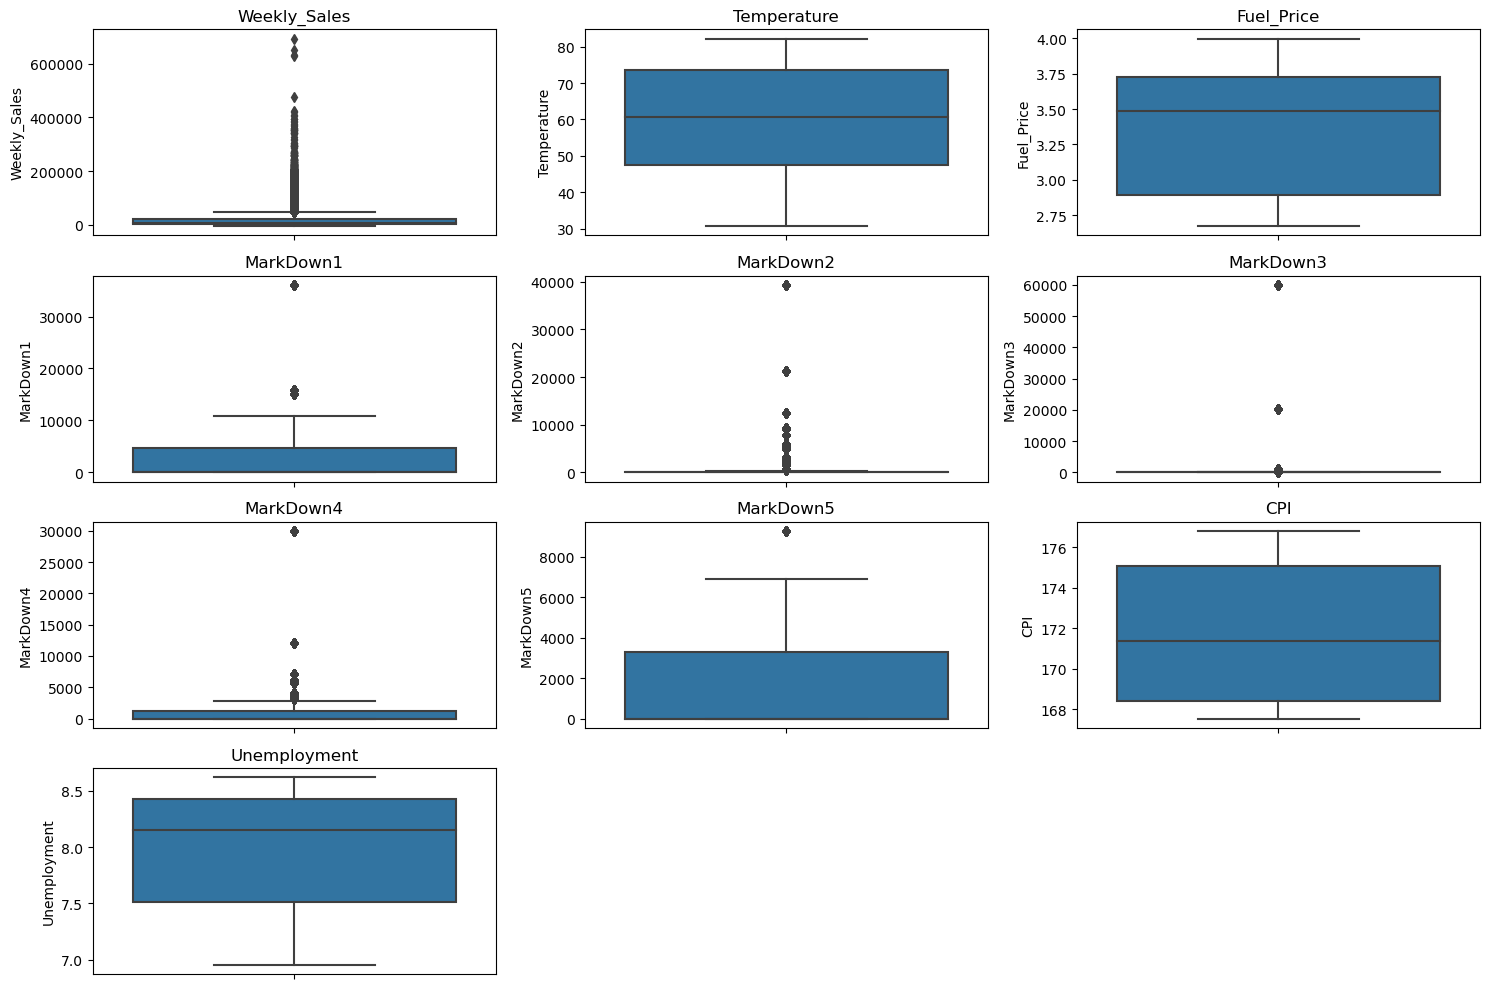

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=final_df, y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

**Based on the outliers detected using IQR methos, we are gonna apply the following strategy**


| Variable               | Outliers | Suggested Action |
|------------------------|----------|-------------------|
| Weekly_Sales           | 35,521   | Capping (winsorization) or log transform |
| MarkDown1              | 8,929    | Capping based on 1st-99th percentiles |
| MarkDown2              | 62,244   | Capping, possibly treat separately due to volume |
| MarkDown3              | 83,060   | Capping + consider missingness patterns |
| MarkDown4              | 32,683   | Capping |
| MarkDown5              | 2,932    | Leave as-is or light capping |
| Temperature, Fuel_Price, CPI, Unemployment | 0 | ✅ No action needed |

In [ ]:
# Define columns to cap
cap_columns = ['Weekly_Sales', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Cap at 1st and 99th percentile
for col in cap_columns:
    lower = final_df[col].quantile(0.01)
    upper = final_df[col].quantile(0.99)
    final_df[col] = final_df[col].clip(lower, upper)
    print(f"{col} capped at 1st and 99th percentiles.")

Weekly_Sales capped at 1st and 99th percentiles.
MarkDown1 capped at 1st and 99th percentiles.
MarkDown2 capped at 1st and 99th percentiles.
MarkDown3 capped at 1st and 99th percentiles.
MarkDown4 capped at 1st and 99th percentiles.
MarkDown5 capped at 1st and 99th percentiles.


In [ ]:
for col in cap_columns:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    final_df[f'{col}_OutlierFlag'] = ((final_df[col] < lower) | (final_df[col] > upper)).astype(int)

## Feature Engineering

#### Date-Based Feature Extraction

In [ ]:
# Ensure 'Date' is in datetime format
final_df['Date'] = pd.to_datetime(final_df['Date'])

# Extract date components
final_df['DayOfWeek'] = final_df['Date'].dt.dayofweek
final_df['Quarter'] = final_df['Date'].dt.quarter
final_df['IsWeekend'] = final_df['DayOfWeek'].isin([5, 6]).astype(int)

#### Change datatype of Month parameter.

In [ ]:
# Dictionary to map month names to numbers
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

# Apply mapping to 'Month' column
final_df['Month'] = final_df['Month'].map(month_map)

#### Change data-type of IsHoliday

Since IsHoliday is currently a bool (True/False), the simplest approach is to convert it to integers:
* True → 1 (holiday)
* False → 0 (non-holiday)

In [ ]:
final_df['IsHoliday'] = final_df['IsHoliday'].astype(int)

#### Encode Categorical Features

In [ ]:
# One-hot encode 'Type' (you could also use Label Encoding if needed)
final_df = pd.get_dummies(final_df, columns=['Type'], prefix='StoreType')

#### Create Lag Features

**These help capture temporal dependencies for time-series models (e.g., sales in previous weeks).**

In [ ]:
# Sort by Store, Dept, Date to prepare for lagging
final_df = final_df.sort_values(['Store', 'Dept', 'Date'])

# Lag 1 week of Weekly Sales
final_df['Weekly_Sales_Lag1'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)

# Lag 2 weeks of Weekly Sales
final_df['Weekly_Sales_Lag2'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2)

#### Rolling Mean and Std

**These smooth fluctuations and show trends over time.**

In [ ]:
# 3-week rolling mean and std
final_df['Weekly_Sales_MA3'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda x: x.rolling(3).mean())
final_df['Weekly_Sales_STD3'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda x: x.rolling(3).std())

#### Holiday Proximity Flags

**Sales are usually affected around holidays.**

In [ ]:
# Previous and next holiday
final_df['IsHoliday_PrevWeek'] = final_df.groupby(['Store'])['IsHoliday'].shift(1)
final_df['IsHoliday_NextWeek'] = final_df.groupby(['Store'])['IsHoliday'].shift(-1)

#### Relative Price and Promotions

**Helps understand elasticity and promo impact.**

In [ ]:
# Fuel price relative to store's average
final_df['Rel_Fuel_Price'] = final_df['Fuel_Price'] / final_df.groupby('Store')['Fuel_Price'].transform('mean')

# Total markdown as promo intensity
final_df['Total_MarkDown'] = final_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].sum(axis=1)

#### Encode Date-Based Seasonality

In [ ]:
# Create cyclic features for week and month
final_df['Week_sin'] = np.sin(2 * np.pi * final_df['Week'] / 52)
final_df['Week_cos'] = np.cos(2 * np.pi * final_df['Week'] / 52)

final_df['Month_sin'] = np.sin(2 * np.pi * final_df['Month'] / 12)
final_df['Month_cos'] = np.cos(2 * np.pi * final_df['Month'] / 12)

#### Statistical Aggregates at Store & Department Level

**Useful for modeling context or baseline sales.**

In [ ]:
# Average sales per store
store_avg = final_df.groupby('Store')['Weekly_Sales'].transform('mean')
final_df['Store_Avg_Sales'] = store_avg

# Average sales per dept
dept_avg = final_df.groupby('Dept')['Weekly_Sales'].transform('mean')
final_df['Dept_Avg_Sales'] = dept_avg

#### Drop or Impute New NaNs (from lags/rolling)

In [ ]:
# Drop rows with new NaNs created by lagging and rolling (first few rows of each group)
final_df.dropna(inplace=True)

**At this point, we are ready for the following**

1. **EDA**: Identify patterns, correlations, seasonalities, anomalies
2. **Modeling**: Train-test split, time series models (ARIMA, SARIMAX), or ML models (XGBoost, LGBM, RNNs)

##### Summary of Engineered Features:
| Feature                             | Description                           |
| ----------------------------------- | ------------------------------------- |
| Weekly\_Sales\_Lag1, Lag2           | Sales in past weeks                   |
| Weekly\_Sales\_MA3, STD3            | Smoothed trend/volatility             |
| IsHoliday\_PrevWeek/NextWeek        | Holiday proximity effect              |
| Rel\_Fuel\_Price                    | Fuel price deviation                  |
| Total\_MarkDown                     | Combined promotion impact             |
| Week\_sin/cos, Month\_sin/cos       | Seasonal cyclical encoding            |
| Store\_Avg\_Sales, Dept\_Avg\_Sales | Baseline reference behavior per group |


# Exploratory Data Analysis

## Trend Analysis

### Weekly Sales Over Time

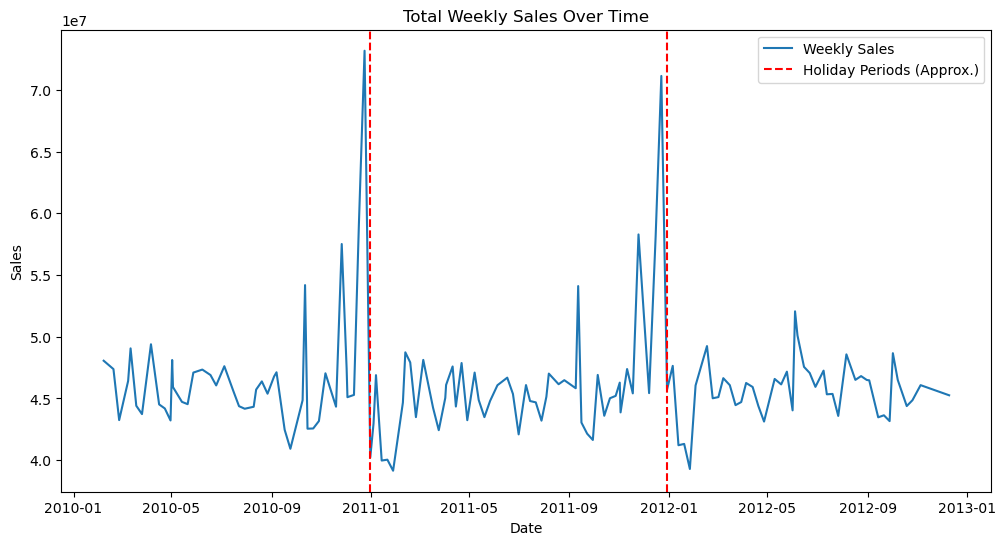

In [ ]:
# Aggregate sales by week to analyze trends
weekly_sales = final_df.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales['Date'], weekly_sales['Weekly_Sales'], label='Weekly Sales')
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.axvline(pd.to_datetime('2010-12-31'), color='r', linestyle='--', label='Holiday Periods (Approx.)')
plt.axvline(pd.to_datetime('2011-12-30'), color='r', linestyle='--')
plt.legend()
plt.show()

### Sales Trend Across Years

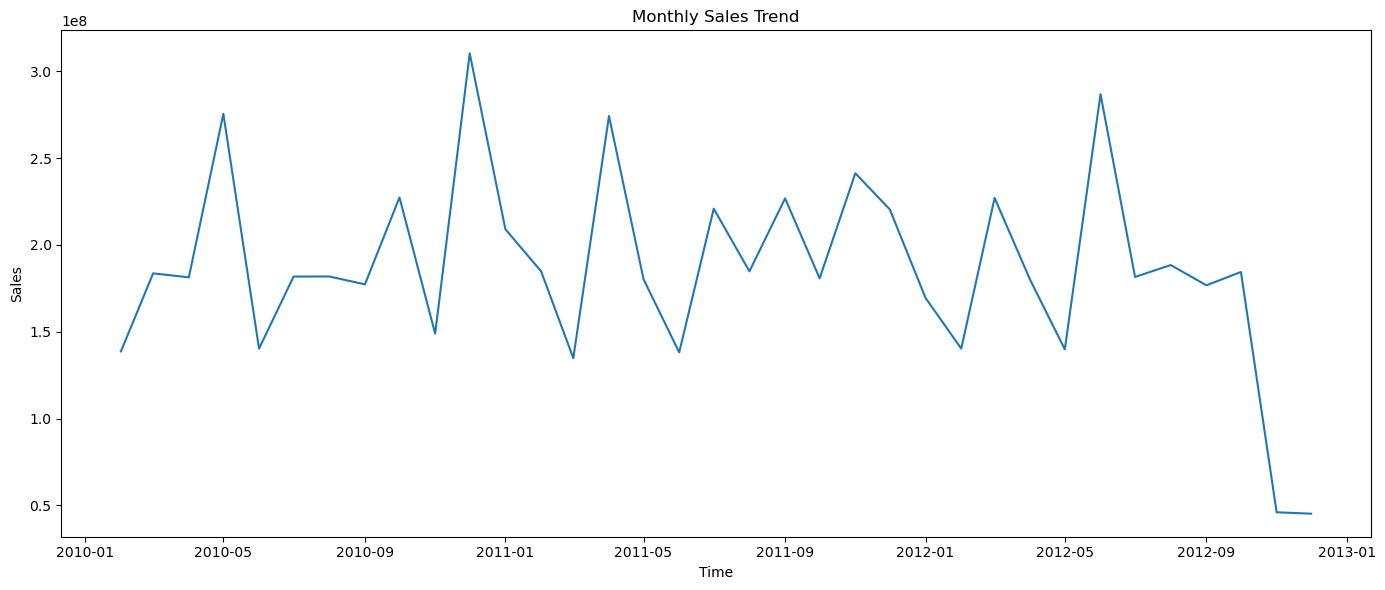

In [ ]:
# Group by year and month
monthly_sales = final_df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str))

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Weekly_Sales')
plt.title('Monthly Sales Trend')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

### Sales Trend Around Holidays

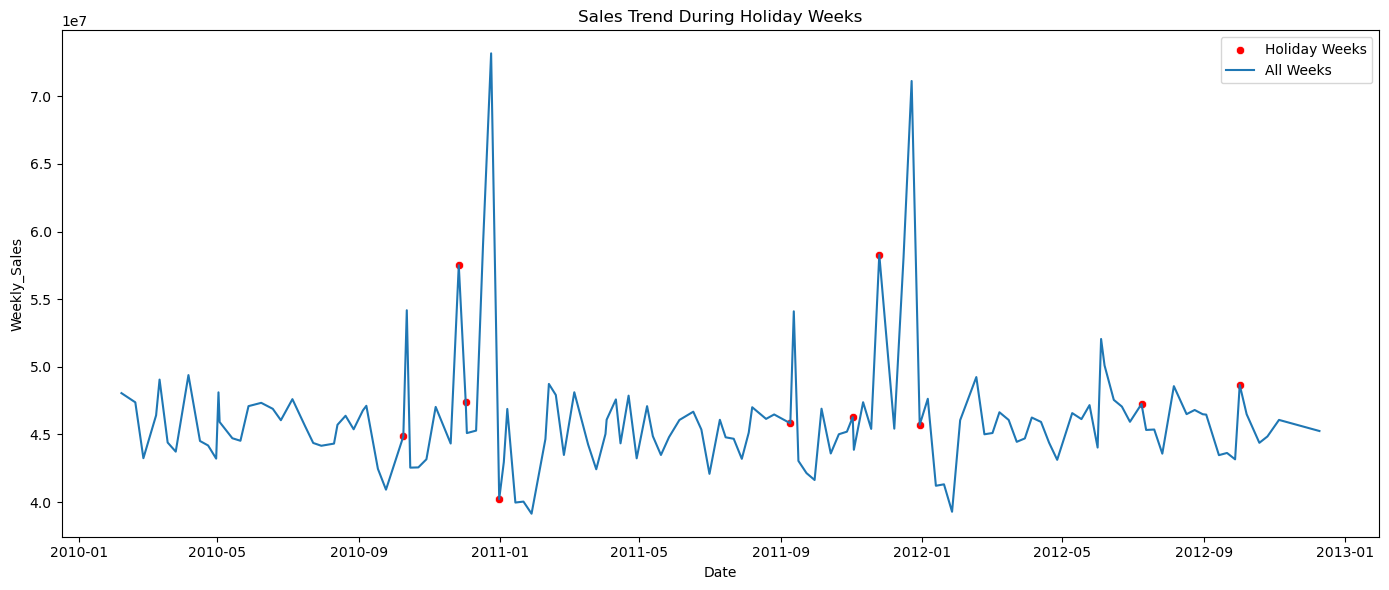

In [ ]:
holiday_sales = final_df[final_df['IsHoliday'] == 1].groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.scatterplot(data=holiday_sales, x='Date', y='Weekly_Sales', color='red', label='Holiday Weeks')
sns.lineplot(data=weekly_sales, x='Date', y='Weekly_Sales', label='All Weeks')
plt.title('Sales Trend During Holiday Weeks')
plt.legend()
plt.tight_layout()
plt.show()

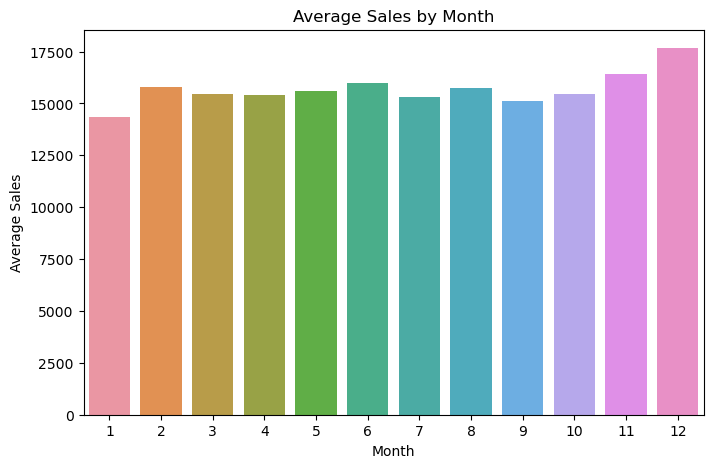

In [ ]:
# Analyze seasonality by month
monthly_sales = final_df.groupby('Month')['Weekly_Sales'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='Month', y='Weekly_Sales', data=monthly_sales)
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

## External Factor Analysis

### Correlation Matrix

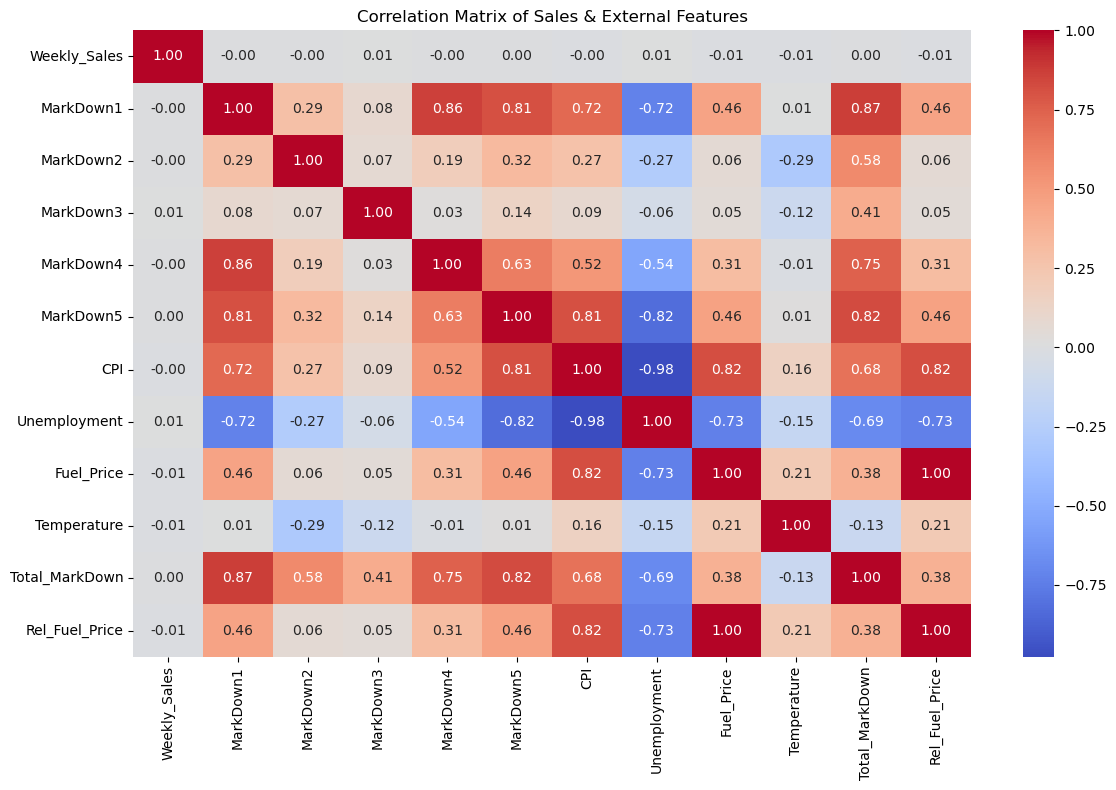

In [ ]:
# Selecting numeric columns of interest
correlation_cols = ['Weekly_Sales', 'MarkDown1', 'MarkDown2', 'MarkDown3',
                    'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Fuel_Price',
                    'Temperature', 'Total_MarkDown', 'Rel_Fuel_Price']

plt.figure(figsize=(12, 8))
sns.heatmap(final_df[correlation_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Sales & External Features')
plt.tight_layout()
plt.show()

### PCA

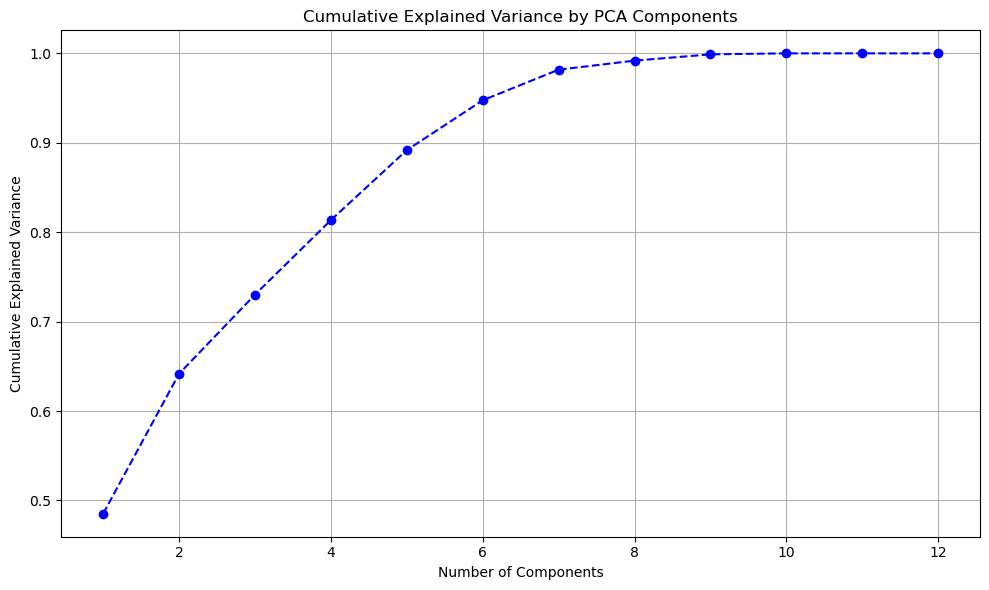

    Component  Explained Variance Ratio  Cumulative Variance
0           1              4.852328e-01             0.485233
1           2              1.565137e-01             0.641747
2           3              8.844153e-02             0.730188
3           4              8.336472e-02             0.813553
4           5              7.823526e-02             0.891788
5           6              5.574746e-02             0.947536
6           7              3.422434e-02             0.981760
7           8              1.008309e-02             0.991843
8           9              7.044567e-03             0.998888
9          10              1.109311e-03             0.999997
10         11              3.185813e-06             1.000000
11         12              2.615142e-31             1.000000

Feature Loadings (First Few PCs):
                  PC1    PC2    PC3    PC4    PC5
Weekly_Sales   -0.002  0.013  0.066  0.992  0.107
MarkDown1       0.363  0.170 -0.286  0.033 -0.145
MarkDown2       0.151 

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'final_df' is your DataFrame and is already loaded
features = [
    "Weekly_Sales", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment", "Fuel_Price", "Temperature", "Total_MarkDown", "Rel_Fuel_Price"
]

# Drop missing values
df_pca = final_df[features].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--', color='b')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

# Explained variance
explained_variance = pd.DataFrame({
    'Component': range(1, len(pca.explained_variance_ratio_) + 1),
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': pca.explained_variance_ratio_.cumsum()
})
print(explained_variance)

# Loadings (Feature Contributions)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features))],
    index=features
)
print("\nFeature Loadings (First Few PCs):")
print(loadings.iloc[:, :5].round(3))  # show first 5 components for brevity

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop identifier columns
X = final_df.drop(columns=["Date", "Store", "Dept"])  # Adjust as needed

# Keep only numeric columns (drop object/categorical columns)
X = X.select_dtypes(include=[np.number])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = np.cumsum(pca.explained_variance_ratio_)

# Loadings matrix
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

# Top N components explaining ≥90% of variance
top_n_pcs = np.argmax(explained_var >= 0.90) + 1

# Identify significant features
significant_features = set()
for pc in loadings.columns[:top_n_pcs]:
    high_impact = loadings[pc].abs() > 0.3  # threshold is tunable
    significant_features.update(loadings[pc][high_impact].index)

# Determine which features to keep/drop
features_to_keep = list(significant_features)
features_to_drop = list(set(X.columns) - set(features_to_keep))

print("✅ Features to KEEP based on PCA:\n", features_to_keep)
print("\n🗑️ Features to DROP/REDUCE based on low contribution:\n", features_to_drop)

✅ Features to KEEP based on PCA:
 ['StoreType_A', 'Weekly_Sales_OutlierFlag', 'MarkDown2', 'Dept_Avg_Sales', 'Weekly_Sales', 'Week_sin', 'Month_sin', 'Temperature', 'Month', 'CPI', 'Weekly_Sales_Lag1', 'Store_Avg_Sales', 'DayOfWeek', 'Weekly_Sales_MA3', 'MarkDown1', 'MarkDown4', 'IsHoliday_PrevWeek', 'Size', 'MarkDown1_OutlierFlag', 'MarkDown4_OutlierFlag', 'IsHoliday_NextWeek', 'MarkDown3_OutlierFlag', 'Year', 'MarkDown2_OutlierFlag', 'Weekly_Sales_Lag2', 'MarkDown3', 'MarkDown5', 'StoreType_B', 'Total_MarkDown', 'Month_cos', 'Weekly_Sales_STD3', 'IsHoliday', 'StoreType_C', 'Unemployment', 'IsWeekend', 'Week', 'Quarter', 'Week_cos']

🗑️ Features to DROP/REDUCE based on low contribution:
 ['Rel_Fuel_Price', 'MarkDown5_OutlierFlag', 'Fuel_Price']


In [ ]:
reduced_df = final_df.drop(columns=['Rel_Fuel_Price', 'MarkDown5_OutlierFlag', 'Fuel_Price'])

### Feature Importance using Random Forest

🔝 Top 20 features based on Random Forest importance:

Weekly_Sales_MA3            0.948346
Weekly_Sales_OutlierFlag    0.026361
Weekly_Sales_STD3           0.011719
Weekly_Sales_Lag1           0.006778
Weekly_Sales_Lag2           0.005908
Week_cos                    0.000173
Week                        0.000133
Dept_Avg_Sales              0.000103
Store_Avg_Sales             0.000052
Temperature                 0.000048
Rel_Fuel_Price              0.000043
Size                        0.000040
Week_sin                    0.000035
MarkDown3                   0.000028
CPI                         0.000026
IsHoliday_NextWeek          0.000023
Fuel_Price                  0.000021
DayOfWeek                   0.000018
Month_cos                   0.000018
Unemployment                0.000015
dtype: float64


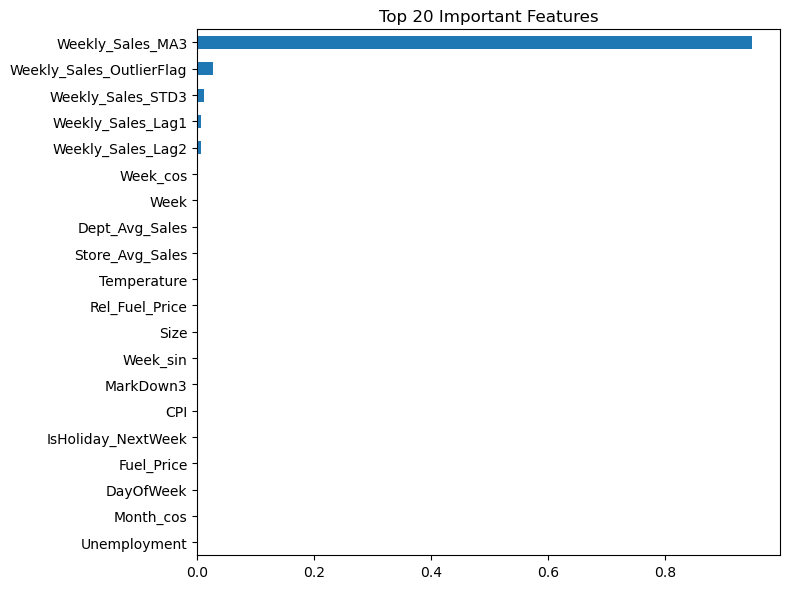

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# Define target and predictors
target = 'Weekly_Sales'  # Replace with your actual target variable
X = final_df.drop(columns=["Date", "Store", "Dept", target])  # Drop identifiers and target
X = X.select_dtypes(include=[np.number])  # Keep only numeric
y = final_df[target]

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Top 20 features
print("🔝 Top 20 features based on Random Forest importance:\n")
print(importances.head(20))

# Optional: Plot
import matplotlib.pyplot as plt
importances.head(20).plot(kind='barh', title='Top 20 Important Features', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Univariate Feature Selection (ANOVA F-test or Mutual Information)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Use numeric predictors
X = final_df.drop(columns=["Date", "Store", "Dept", target])
X = X.select_dtypes(include=[np.number])
y = final_df[target]

# Apply univariate selection
selector = SelectKBest(score_func=f_regression, k=20)  # Select top 20
X_new = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("🔍 Top 20 features by ANOVA F-test:\n", selected_features.tolist())

🔍 Top 20 features by ANOVA F-test:
 ['Week', 'Month', 'Year', 'Fuel_Price', 'MarkDown3', 'Size', 'Weekly_Sales_OutlierFlag', 'Quarter', 'StoreType_A', 'StoreType_B', 'StoreType_C', 'Weekly_Sales_Lag1', 'Weekly_Sales_Lag2', 'Weekly_Sales_MA3', 'Weekly_Sales_STD3', 'IsHoliday_NextWeek', 'Week_cos', 'Month_cos', 'Store_Avg_Sales', 'Dept_Avg_Sales']


### Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=20)
rfe.fit(X, y)

selected_features_rfe = X.columns[rfe.support_]
print("🔁 Top 20 features selected by RFE:\n", selected_features_rfe.tolist())

🔁 Top 20 features selected by RFE:
 ['IsHoliday', 'Year', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Weekly_Sales_OutlierFlag', 'MarkDown1_OutlierFlag', 'MarkDown2_OutlierFlag', 'MarkDown3_OutlierFlag', 'StoreType_A', 'StoreType_B', 'StoreType_C', 'Weekly_Sales_Lag1', 'Weekly_Sales_Lag2', 'Weekly_Sales_MA3', 'Rel_Fuel_Price', 'Total_MarkDown']


### Drop Low-Importance Features

In [ ]:
# Features to drop (from consolidated analysis)
features_to_drop = [
    'CPI', 'Unemployment', 'Temperature', 'IsWeekend',
    'IsHoliday', 'Week_sin', 'Month_sin', 'Month_cos', 'Week_cos',
    'Quarter', 'Week', 'Month', 'DayOfWeek'
]

# Drop them from the dataset
X_selected = final_df.drop(columns=features_to_drop, errors='ignore')

# Verify
print("Remaining features after drop:", X_selected.columns.tolist())

Remaining features after drop: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'Year', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Size', 'Weekly_Sales_OutlierFlag', 'MarkDown1_OutlierFlag', 'MarkDown2_OutlierFlag', 'MarkDown3_OutlierFlag', 'MarkDown4_OutlierFlag', 'MarkDown5_OutlierFlag', 'StoreType_A', 'StoreType_B', 'StoreType_C', 'Weekly_Sales_Lag1', 'Weekly_Sales_Lag2', 'Weekly_Sales_MA3', 'Weekly_Sales_STD3', 'IsHoliday_PrevWeek', 'IsHoliday_NextWeek', 'Rel_Fuel_Price', 'Total_MarkDown', 'Store_Avg_Sales', 'Dept_Avg_Sales']


## Department & Store Level Trends

### Average Sales per Store

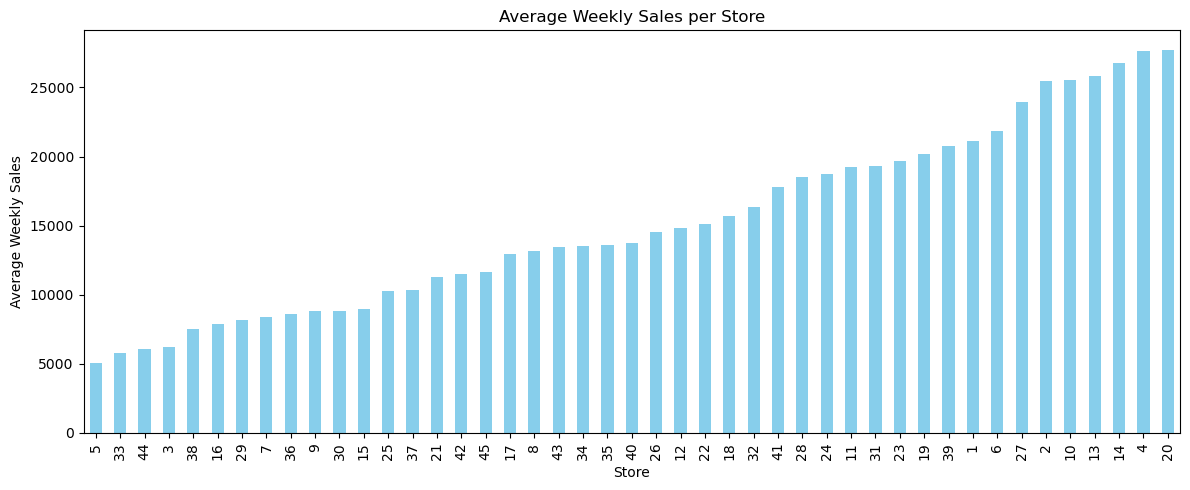

In [ ]:
store_sales = final_df.groupby('Store')['Weekly_Sales'].mean().sort_values()

plt.figure(figsize=(12, 5))
store_sales.plot(kind='bar', color='skyblue')
plt.title('Average Weekly Sales per Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.show()

### Average Sales per Department

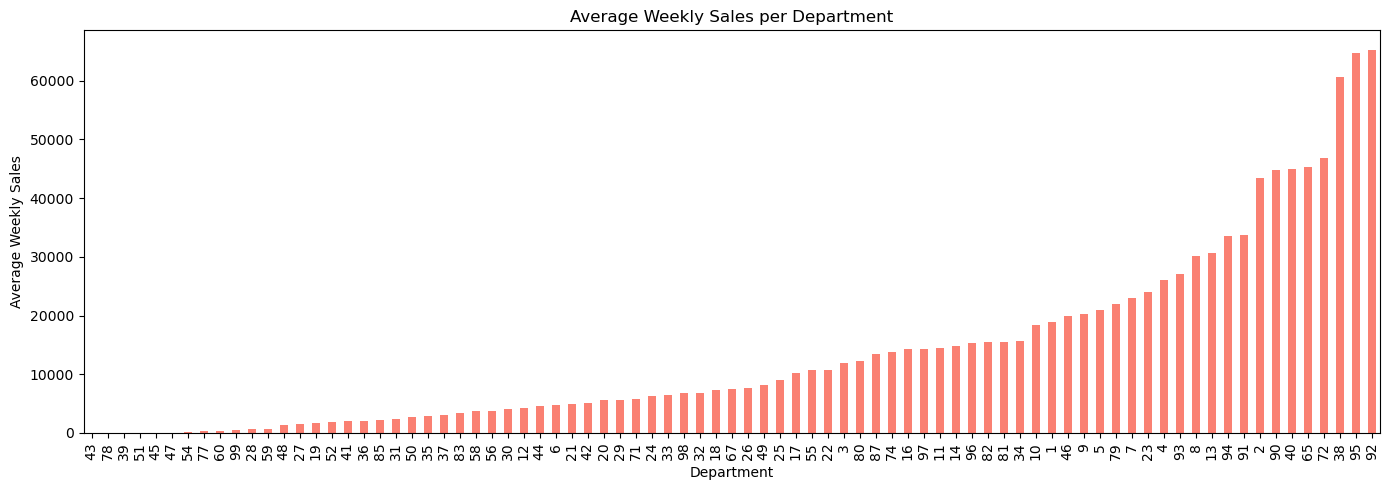

In [ ]:
dept_sales = final_df.groupby('Dept')['Weekly_Sales'].mean().sort_values()

plt.figure(figsize=(14, 5))
dept_sales.plot(kind='bar', color='salmon')
plt.title('Average Weekly Sales per Department')
plt.xlabel('Department')
plt.ylabel('Average Weekly Sales')
plt.tight_layout()
plt.show()

### Weekly Sales vs. Lag Features

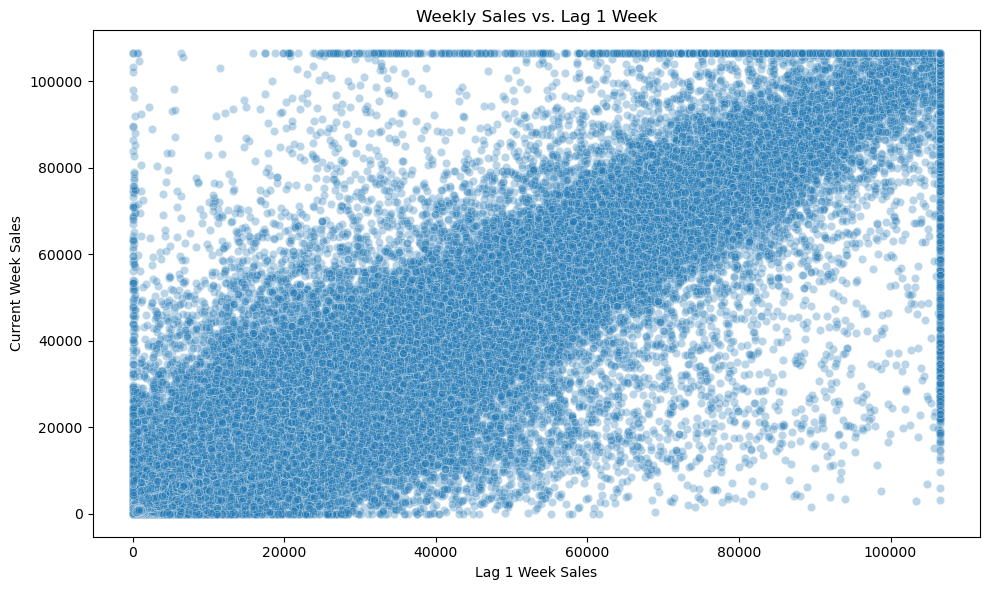

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=final_df['Weekly_Sales_Lag1'], y=final_df['Weekly_Sales'], alpha=0.3)
plt.title('Weekly Sales vs. Lag 1 Week')
plt.xlabel('Lag 1 Week Sales')
plt.ylabel('Current Week Sales')
plt.tight_layout()
plt.show()

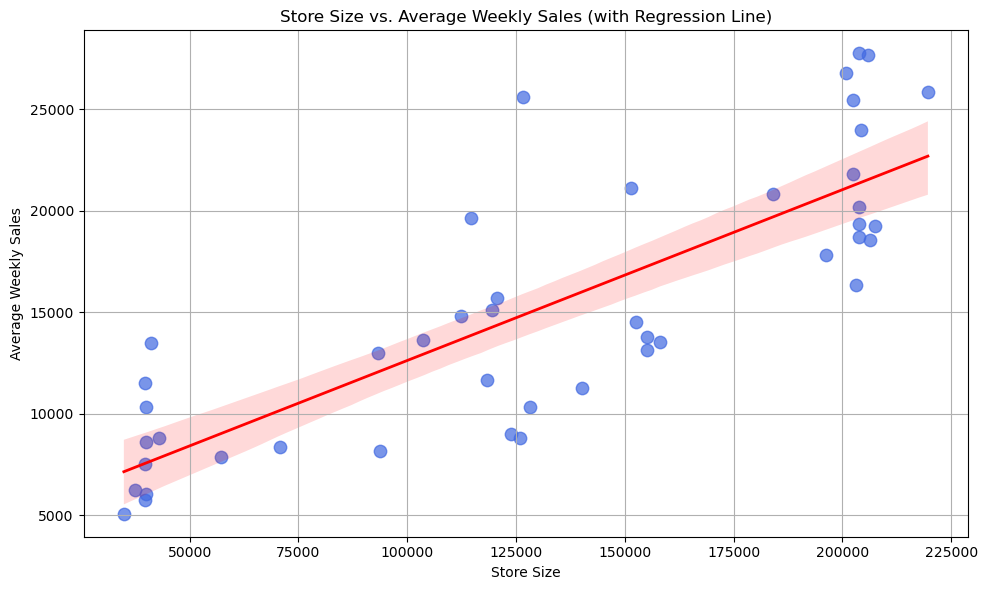

In [ ]:
# Grouping to get average weekly sales per store
store_sales = final_df.groupby('Store').agg({
    'Weekly_Sales': 'mean',
    'Size': 'first'  # Assuming Size is constant per store
}).reset_index()

# Plotting scatter with regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=store_sales, x='Size', y='Weekly_Sales', scatter_kws={'s': 80, 'color': 'royalblue', 'alpha': 0.7},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Store Size vs. Average Weekly Sales (with Regression Line)')
plt.xlabel('Store Size')
plt.ylabel('Average Weekly Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

### Rolling Mean & Std

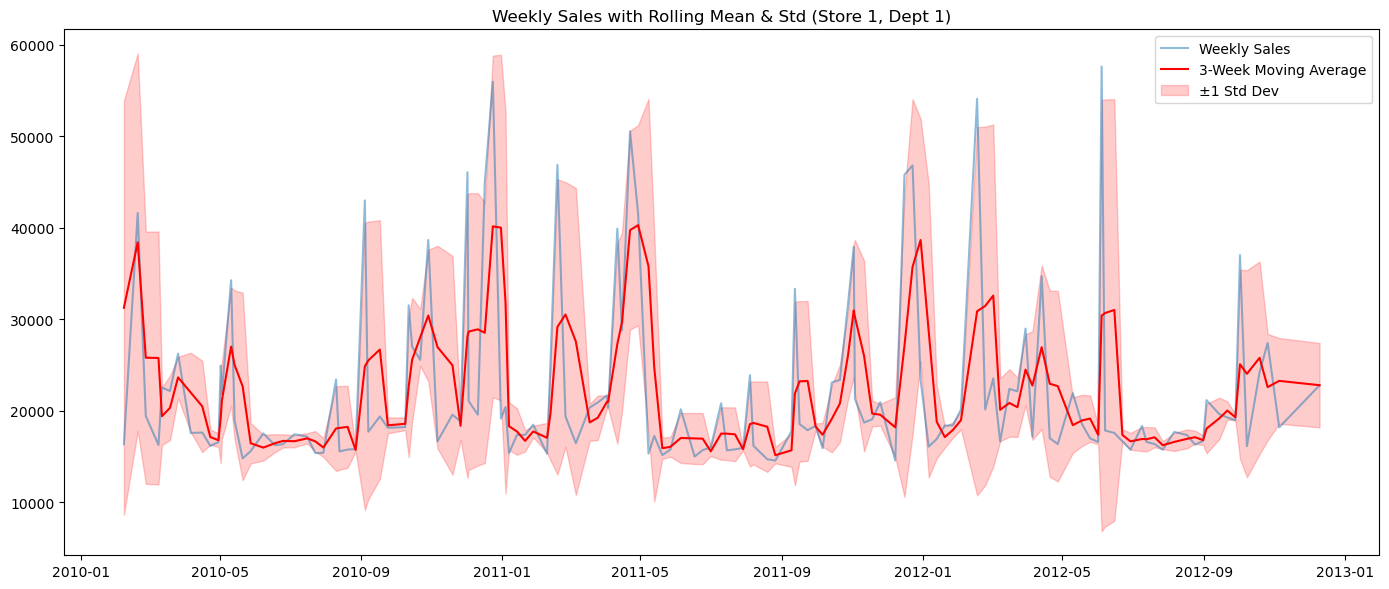

In [ ]:
# Plot a sample store/department
sample = final_df[(final_df['Store'] == 1) & (final_df['Dept'] == 1)].sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(sample['Date'], sample['Weekly_Sales'], label='Weekly Sales', alpha=0.5)
plt.plot(sample['Date'], sample['Weekly_Sales_MA3'], label='3-Week Moving Average', color='red')
plt.fill_between(sample['Date'],
                 sample['Weekly_Sales_MA3'] - sample['Weekly_Sales_STD3'],
                 sample['Weekly_Sales_MA3'] + sample['Weekly_Sales_STD3'],
                 color='red', alpha=0.2, label='±1 Std Dev')
plt.title('Weekly Sales with Rolling Mean & Std (Store 1, Dept 1)')
plt.legend()
plt.tight_layout()
plt.show()

### Trend of Store Type Over Time

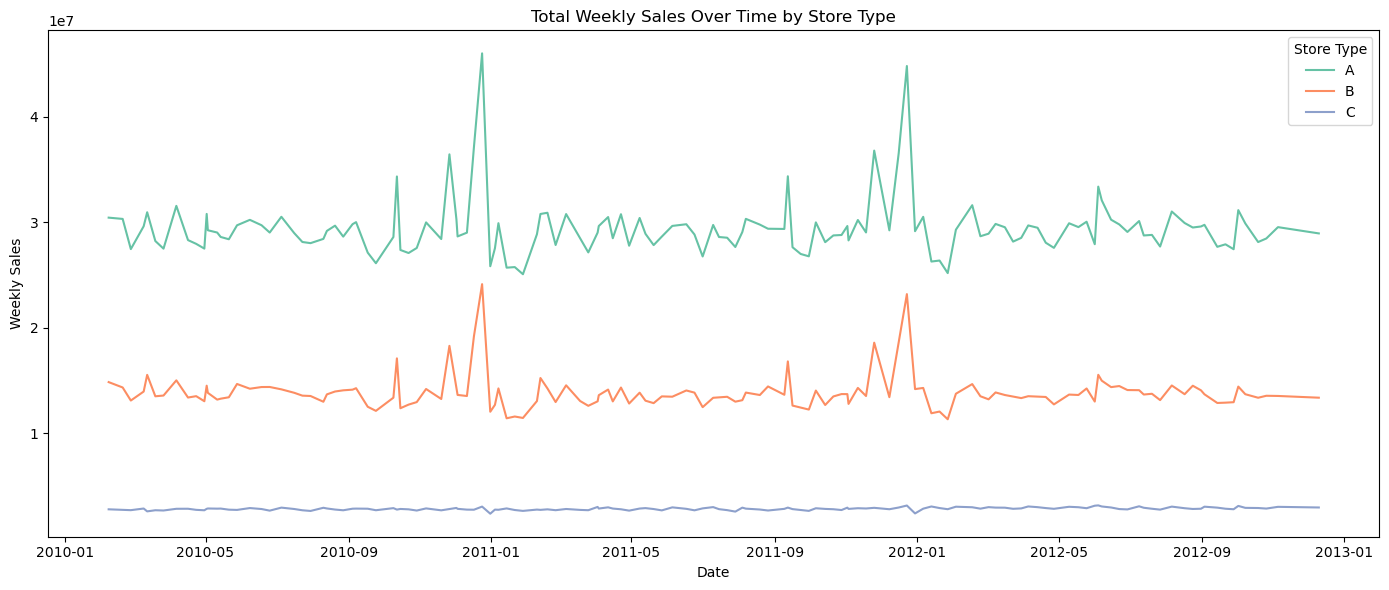

In [ ]:
# Ensure there's only one type per store
def get_store_type(row):
    if row['StoreType_A'] == 1:
        return 'A'
    elif row['StoreType_B'] == 1:
        return 'B'
    elif row['StoreType_C'] == 1:
        return 'C'
    else:
        return 'Unknown'

# Add 'StoreType' column
final_df['StoreType'] = final_df.apply(get_store_type, axis=1)

# Group by Date and StoreType and aggregate Weekly_Sales
sales_by_type = final_df.groupby(['Date', 'StoreType'])['Weekly_Sales'].sum().reset_index()

# Sort values to avoid plotting issues
sales_by_type.sort_values(by='Date', inplace=True)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=sales_by_type, x='Date', y='Weekly_Sales', hue='StoreType', palette='Set2')
plt.title('Total Weekly Sales Over Time by Store Type')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend(title='Store Type')
plt.tight_layout()
plt.show()

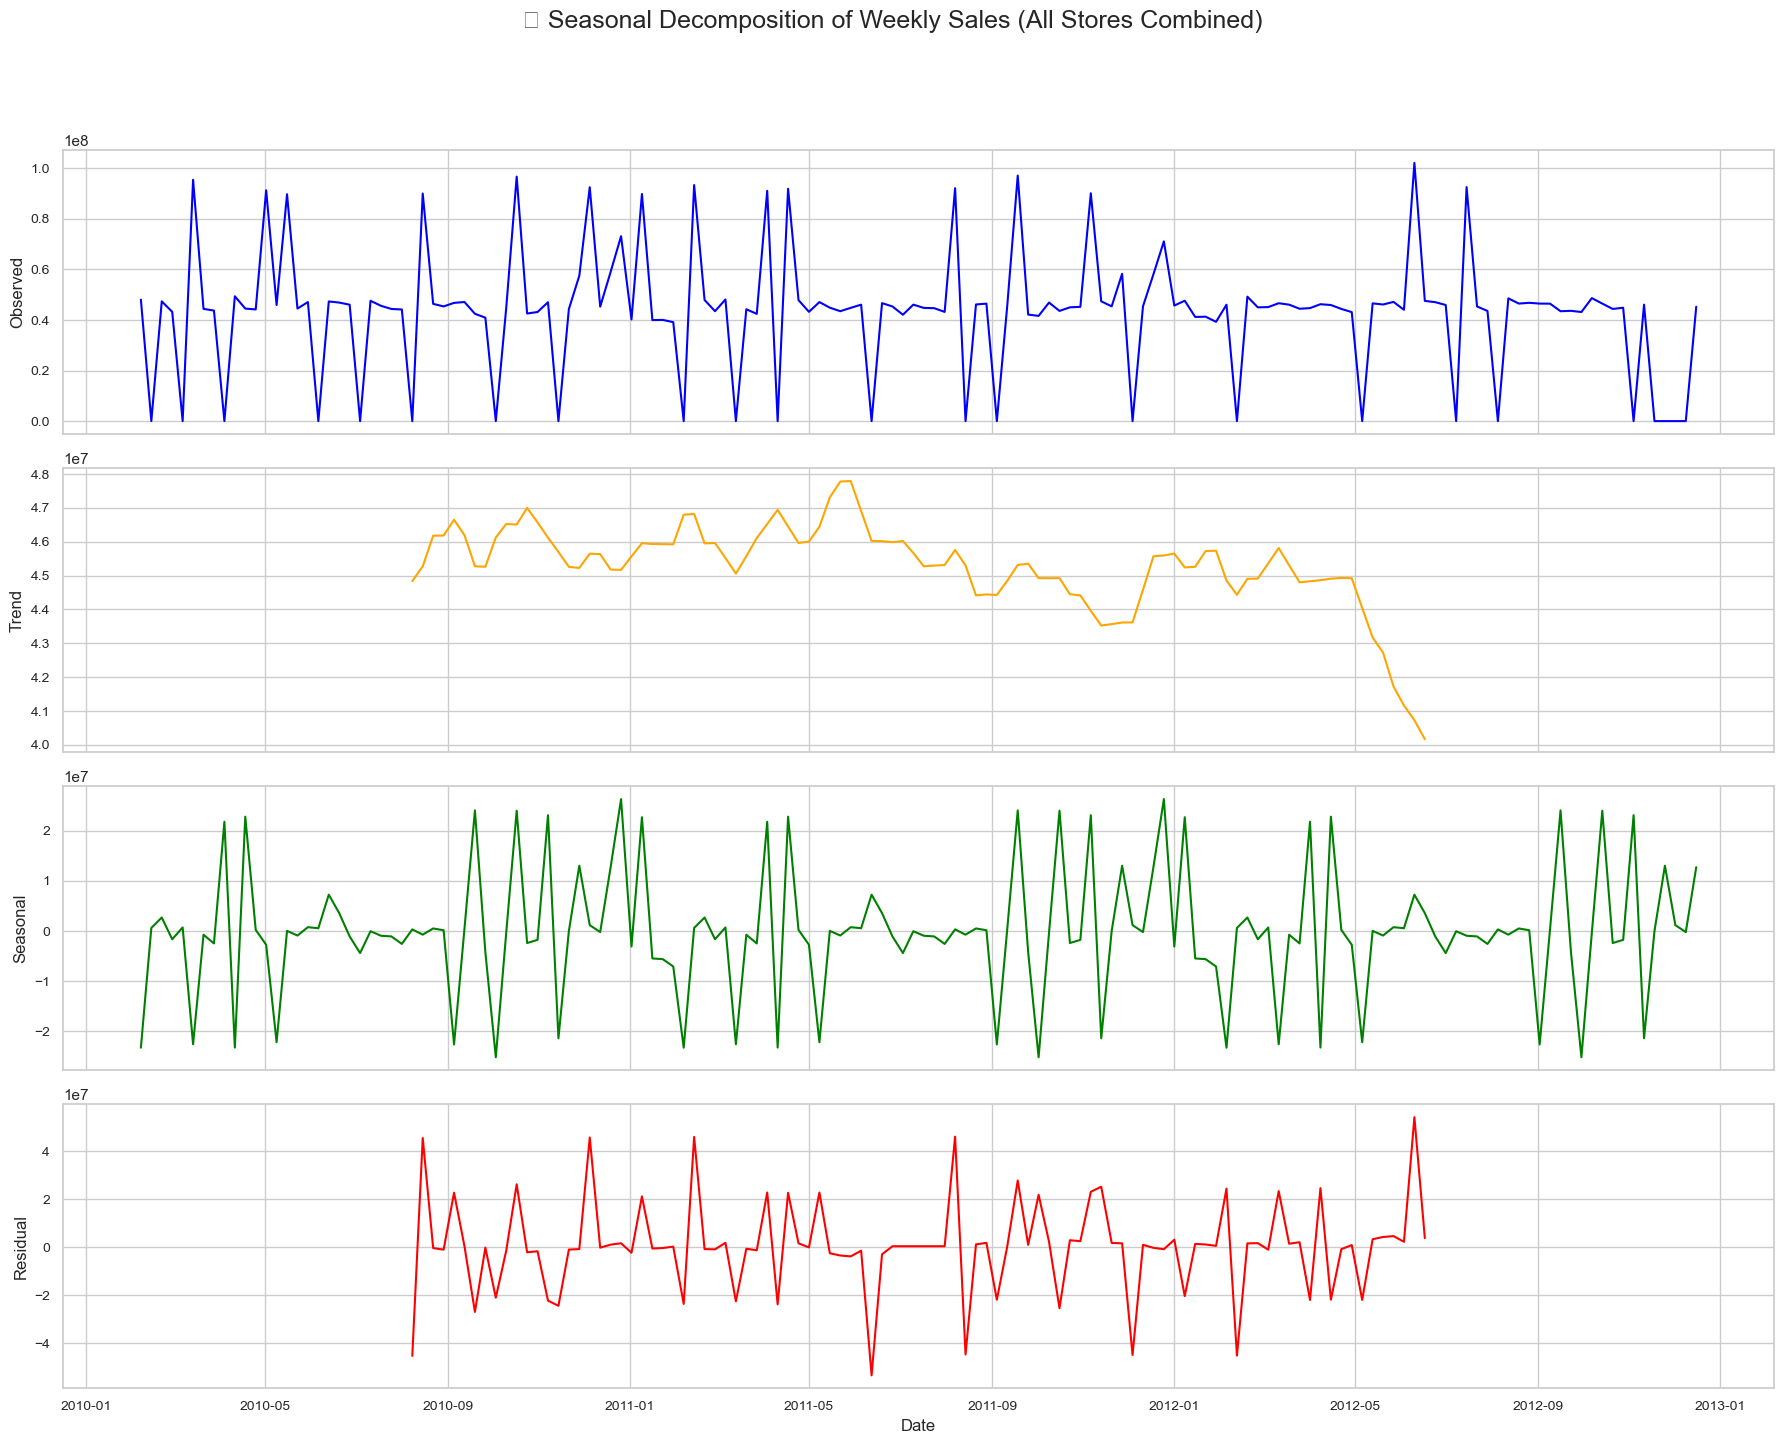

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Ensure datetime format and set index
final_df['Date'] = pd.to_datetime(final_df['Date'])
final_df.set_index('Date', inplace=True)

# Aggregate total weekly sales
weekly_sales_total = final_df['Weekly_Sales'].resample('W').sum()

# Perform seasonal decomposition
decomposition = seasonal_decompose(weekly_sales_total, model='additive', period=52)

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid
observed = decomposition.observed

# Plot with improved layout and labels
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
fig.suptitle('📈 Seasonal Decomposition of Weekly Sales (All Stores Combined)', fontsize=18, y=1.03)

# Observed
axes[0].plot(observed, color='blue')
axes[0].set_ylabel('Observed', fontsize=12)

# Trend
axes[1].plot(trend, color='orange')
axes[1].set_ylabel('Trend', fontsize=12)

# Seasonal
axes[2].plot(seasonal, color='green')
axes[2].set_ylabel('Seasonal', fontsize=12)

# Residual
axes[3].plot(residual, color='red')
axes[3].set_ylabel('Residual', fontsize=12)
axes[3].set_xlabel('Date', fontsize=12)

# Styling
for ax in axes:
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Adjust to fit suptitle
plt.show()

# Reset index after plotting
final_df.reset_index(inplace=True)

# Model Development

## Baseline Model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Copy dataset
df = final_df.copy()

# Train-validation split
train = df[df['Date'] < '2012-01-01']
valid = df[(df['Date'] >= '2012-01-01') & (df['Date'] <= '2012-11-01')]

# Baseline prediction using Dept_Avg_Sales
valid['Pred_Baseline'] = valid['Dept_Avg_Sales']

# Evaluation Function
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n🔍 Evaluation Results for {model_name}")
    print(f"📊 MAE : {mae:.2f}")
    print(f"📉 RMSE: {rmse:.2f}")
    print(f"📈 R²  : {r2:.4f}")
    print(f"📐 MAPE: {mape:.2f}%")

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

# Run baseline evaluation
baseline_metrics = evaluate_model(valid['Weekly_Sales'], valid['Pred_Baseline'], model_name="Baseline (Dept_Avg_Sales)")


🔍 Evaluation Results for Baseline (Dept_Avg_Sales)
📊 MAE : 8034.44
📉 RMSE: 13121.51
📈 R²  : 0.5970
📐 MAPE: 3007.97%


## Time Series Model (ARIMA)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prepare to store forecasts
arima_forecasts = []

# Unique store-department pairs
unique_pairs = valid[['Store', 'Dept']].drop_duplicates()

# Loop through each Store-Dept combination
for _, row in tqdm(unique_pairs.iterrows(), total=len(unique_pairs), desc="Fitting ARIMA models"):
    store_id, dept_id = row['Store'], row['Dept']

    # Subset training time series
    train_subset = train[(train['Store'] == store_id) & (train['Dept'] == dept_id)].sort_values('Date')
    ts = train_subset.set_index('Date')['Weekly_Sales']

    if len(ts) < 10:
        continue

    # Subset validation data for same pair
    valid_subset = valid[(valid['Store'] == store_id) & (valid['Dept'] == dept_id)].sort_values('Date')
    n_forecast = len(valid_subset)
    if n_forecast == 0:
        continue

    try:
        model = ARIMA(ts, order=(1, 1, 1))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=n_forecast)

        # Add forecasts
        df_forecast = valid_subset.copy()
        df_forecast['Pred_ARIMA'] = forecast.values
        arima_forecasts.append(df_forecast[['Store', 'Dept', 'Date', 'Weekly_Sales', 'Pred_ARIMA']])

    except Exception as e:
        print(f"❌ ARIMA failed for Store {store_id}, Dept {dept_id}: {e}")
        continue

# Combine forecasts
arima_all = pd.concat(arima_forecasts)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n📊 Evaluation Results: {model_name}")
    print(f"🔸 MAE : {mae:.2f}")
    print(f"🔸 RMSE: {rmse:.2f}")
    print(f"🔸 R²  : {r2:.4f}")
    print(f"🔸 MAPE: {mape:.2f}%")

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

# Run evaluation for ARIMA
evaluate_model(arima_all['Weekly_Sales'], arima_all['Pred_ARIMA'], model_name="ARIMA (All Store-Dept)")

Fitting ARIMA models: 100%|█████████████████| 3190/3190 [01:46<00:00, 29.83it/s]



📊 Evaluation Results: ARIMA (All Store-Dept)
🔸 MAE : 3267.73
🔸 RMSE: 6564.49
🔸 R²  : 0.8995
🔸 MAPE: 835.86%


{'MAE': 3267.7270722623416,
 'RMSE': 6564.493426483747,
 'R2': 0.8994526681887526,
 'MAPE': 835.8615624599091}

## Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features
features = [
    'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size',
    'StoreType_A', 'StoreType_B', 'StoreType_C', 'MarkDown1', 'MarkDown2',
    'MarkDown3', 'MarkDown4', 'MarkDown5', 'Total_MarkDown', 'Week_sin',
    'Week_cos', 'Month_sin', 'Month_cos', 'Weekly_Sales_Lag1',
    'Weekly_Sales_Lag2', 'Weekly_Sales_MA3', 'Weekly_Sales_STD3',
    'IsHoliday_PrevWeek', 'IsHoliday_NextWeek', 'Rel_Fuel_Price',
    'Store_Avg_Sales', 'Dept_Avg_Sales'
]

# Split into train and validation sets
X_train = train[features]
y_train = train['Weekly_Sales']
X_valid = valid[features]
y_valid = valid['Weekly_Sales']

# Fit Random Forest model
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_valid)

# Evaluation metrics
mae_rf = mean_absolute_error(y_valid, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_valid, pred_rf))
r2_rf = r2_score(y_valid, pred_rf)
mape_rf = np.mean(np.abs((y_valid - pred_rf) / y_valid)) * 100

# Print results
print(f"\n🔹 Random Forest Model Evaluation:")
print(f"MAE   : {mae_rf:.2f}")
print(f"RMSE  : {rmse_rf:.2f}")
print(f"R²    : {r2_rf:.4f}")
print(f"MAPE  : {mape_rf:.2f}%")


🔹 Random Forest Model Evaluation:
MAE   : 910.24
RMSE  : 1729.62
R²    : 0.9930
MAPE  : 78.07%


### XGBoost with Hyperparameter Tuning

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Define hyperparameter grid
params = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [6, 10]
}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=3)
grid_xgb = GridSearchCV(
    xgb,
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

# Predict using best estimator
best_xgb = grid_xgb.best_estimator_
pred_xgb = best_xgb.predict(X_valid)

# Evaluation Metrics
mae_xgb = mean_absolute_error(y_valid, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, pred_xgb))
r2_xgb = r2_score(y_valid, pred_xgb)
mape_xgb = np.mean(np.abs((y_valid - pred_xgb) / y_valid)) * 100

# Results
print(f"\n🔹 XGBoost Model Evaluation")
print(f"Best Parameters : {grid_xgb.best_params_}")
print(f"MAE             : {mae_xgb:.2f}")
print(f"RMSE            : {rmse_xgb:.2f}")
print(f"R²              : {r2_xgb:.4f}")
print(f"MAPE            : {mape_xgb:.2f}%")


Fitting 3 folds for each of 4 candidates, totalling 12 fits

🔹 XGBoost Model Evaluation
Best Parameters : {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}
MAE             : 335.13
RMSE            : 881.15
R²              : 0.9982
MAPE            : 53.34%


### **Forecasting**

#### Baseline

In [ ]:
import pandas as pd

# Step 1: Compute department-wise average from training data
dept_avg_sales = train.groupby('Dept')['Weekly_Sales'].mean().reset_index()
dept_avg_sales.columns = ['Dept', 'Dept_Avg_Sales']

# Step 2: Merge Dept_Avg_Sales with test_df
test_with_preds = test_df.merge(dept_avg_sales, on='Dept', how='left')

# Step 3: Create prediction column
test_with_preds['Predicted_Weekly_Sales'] = test_with_preds['Dept_Avg_Sales']

# Step 4: Keep final columns for export or review
forecast_baseline = test_with_preds[['Store', 'Dept', 'Date', 'Predicted_Weekly_Sales']]

# Optional: Save predictions to CSV
forecast_baseline.to_csv("baseline_predictions.csv", index=False)

# Display sample
print(forecast_baseline.head())

   Store  Dept       Date  Predicted_Weekly_Sales
0      1     1 2012-11-02            19189.218165
1      1     1 2012-11-09            19189.218165
2      1     1 2012-11-16            19189.218165
3      1     1 2012-11-23            19189.218165
4      1     1 2012-11-30            19189.218165


#### ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from tqdm import tqdm
import pandas as pd
import numpy as np

# Store predictions
arima_test_forecasts = []

# Get unique Store-Dept combinations from test_df
unique_pairs_test = test_df[['Store', 'Dept']].drop_duplicates()

# Iterate through each Store-Dept combo
for _, row in tqdm(unique_pairs_test.iterrows(), total=len(unique_pairs_test), desc="Forecasting on Test Set"):
    store_id, dept_id = row['Store'], row['Dept']

    # Get training data for this combination
    ts_train = train[(train['Store'] == store_id) & (train['Dept'] == dept_id)].sort_values('Date')
    ts = ts_train.set_index('Date')['Weekly_Sales']

    if len(ts) < 10:
        continue  # Skip short series

    # Get test period for same Store-Dept
    ts_test = test_df[(test_df['Store'] == store_id) & (test_df['Dept'] == dept_id)].sort_values('Date')
    n_forecast = len(ts_test)

    if n_forecast == 0:
        continue

    try:
        # Fit ARIMA
        model = ARIMA(ts, order=(1, 1, 1))
        model_fit = model.fit()

        # Forecast
        forecast = model_fit.forecast(steps=n_forecast)

        # Merge with test_df subset
        df_forecast = ts_test.copy()
        df_forecast['Predicted_Weekly_Sales'] = forecast.values
        arima_test_forecasts.append(df_forecast[['Store', 'Dept', 'Date', 'Predicted_Weekly_Sales']])

    except Exception as e:
        print(f"⚠️ ARIMA failed for Store {store_id}, Dept {dept_id}: {e}")
        continue

# Combine all forecasts into a single DataFrame
arima_test_all = pd.concat(arima_test_forecasts, ignore_index=True)

# Save to CSV (optional)
arima_test_all.to_csv("arima_test_forecasts.csv", index=False)

# Preview
print(arima_test_all.head())

Forecasting on Test Set: 100%|██████████████| 3169/3169 [01:41<00:00, 31.15it/s]


   Store  Dept       Date  Predicted_Weekly_Sales
0      1     1 2012-11-02            22833.998374
1      1     1 2012-11-09            22686.604837
2      1     1 2012-11-16            22644.574217
3      1     1 2012-11-23            22632.588801
4      1     1 2012-11-30            22629.171049


#### Random Forest

In [ ]:
# Define exact features used in training
rf_features = [
    'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size',
    'StoreType_A', 'StoreType_B', 'StoreType_C', 'MarkDown1', 'MarkDown2',
    'MarkDown3', 'MarkDown4', 'MarkDown5', 'Total_MarkDown', 'Week_sin',
    'Week_cos', 'Month_sin', 'Month_cos', 'Weekly_Sales_Lag1',
    'Weekly_Sales_Lag2', 'Weekly_Sales_MA3', 'Weekly_Sales_STD3',
    'IsHoliday_PrevWeek', 'IsHoliday_NextWeek', 'Rel_Fuel_Price',
    'Store_Avg_Sales', 'Dept_Avg_Sales'
]

# Drop duplicate StoreType columns (if any)
df_test = df_test.loc[:, ~df_test.columns.duplicated()]

# Select only the features used during training
X_test = df_test[rf_features]

# Make predictions
df_test['Predicted_Weekly_Sales'] = rf.predict(X_test)

# Save the forecasted results to a CSV file
df_test.to_csv("forecasted_weekly_sales.csv", index=False)

print("✅ Forecast saved to 'forecasted_weekly_sales.csv'")

✅ Forecast saved to 'forecasted_weekly_sales.csv'


In [ ]:
df_test.head()

,Store,Dept,Date,IsHoliday,Week,Month,Year,Temperature,Fuel_Price,MarkDown1,...,IsHoliday_PrevWeek,IsHoliday_NextWeek,Rel_Fuel_Price,Store_Avg_Sales,Dept_Avg_Sales,DayOfWeek,Quarter,IsWeekend,StoreType,Predicted_Weekly_Sales
0,1,1,2012-11-02,0,44,11,2012,54.615556,3.676289,8478.388182,...,0.0,0.0,1.027179,21094.792865,18896.476395,4,4,0,A,10.061559
1,1,1,2012-11-09,0,45,11,2012,52.718889,3.603111,7188.592000,...,0.0,0.0,1.006733,21094.792865,18896.476395,4,4,0,A,10.061559
2,1,1,2012-11-16,0,46,11,2012,47.114444,3.549289,10216.026222,...,0.0,1.0,0.991695,21094.792865,18896.476395,4,4,0,A,10.061559
3,1,1,2012-11-23,1,47,11,2012,49.637778,3.526311,1236.118444,...,0.0,0.0,0.985274,21094.792865,18896.476395,4,4,0,A,10.061559
4,1,1,2012-11-30,0,48,11,2012,45.773333,3.502067,2912.441778,...,1.0,0.0,0.978500,21094.792865,18896.476395,4,4,0,A,10.061559


### Feature Importance Plots

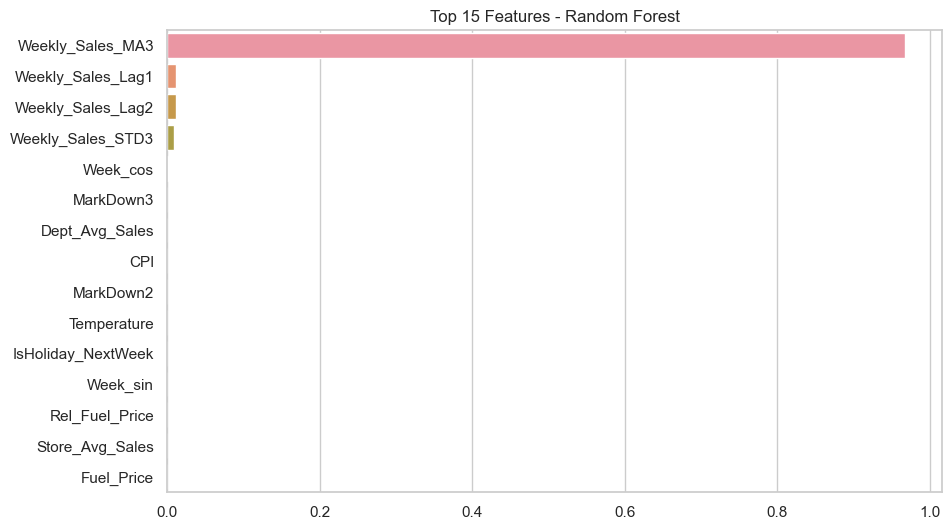

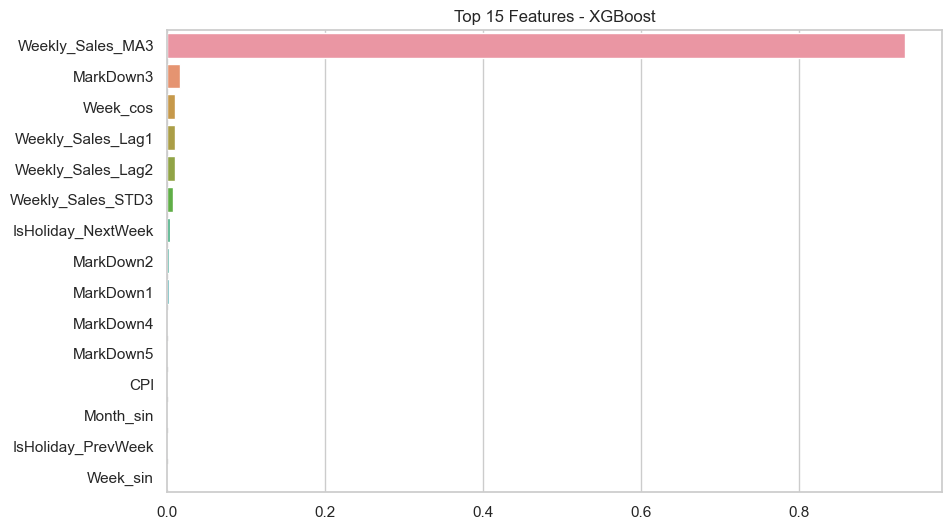

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest Feature Importance
rf_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_imp.values[:15], y=rf_imp.index[:15])
plt.title("Top 15 Features - Random Forest")
plt.show()

# XGBoost Feature Importance
xgb_imp = pd.Series(best_xgb.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_imp.values[:15], y=xgb_imp.index[:15])
plt.title("Top 15 Features - XGBoost")
plt.show()

In [ ]:
mae_baseline = mean_absolute_error(valid['Weekly_Sales'], valid['Pred_Baseline'])
rmse_baseline = np.sqrt(mean_squared_error(valid['Weekly_Sales'], valid['Pred_Baseline']))
r2_baseline = None
mape_baseline = None

In [ ]:
mae_arima = mean_absolute_error(arima_all['Weekly_Sales'], arima_all['Pred_ARIMA'])
rmse_arima = np.sqrt(mean_squared_error(arima_all['Weekly_Sales'], arima_all['Pred_ARIMA']))
r2_arima = r2_score(arima_all['Weekly_Sales'], arima_all['Pred_ARIMA'])
mape_arima = np.mean(np.abs((arima_all['Weekly_Sales'] - arima_all['Pred_ARIMA']) / arima_all['Weekly_Sales'])) * 100

In [ ]:
mae_rf = mean_absolute_error(y_valid, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_valid, pred_rf))
r2_rf = r2_score(y_valid, pred_rf)
mape_rf = np.mean(np.abs((y_valid - pred_rf) / y_valid)) * 100

In [ ]:
mae_xgb = mean_absolute_error(y_valid, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, pred_xgb))
r2_xgb = r2_score(y_valid, pred_xgb)
mape_xgb = np.mean(np.abs((y_valid - pred_xgb) / y_valid)) * 100

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline (Dept Avg)", "ARIMA", "Random Forest", "XGBoost"],
    "MAE": [mae_baseline, mae_arima, mae_rf, mae_xgb],
    "RMSE": [rmse_baseline, rmse_arima, rmse_rf, rmse_xgb],
    "R² Score": [r2_baseline, r2_arima, r2_rf, r2_xgb],
    "MAPE (%)": [mape_baseline, mape_arima, mape_rf, mape_xgb]
})

# Format output
comparison_df = comparison_df.round(2)

# Display table
print("\n📊 Model Performance Comparison")
print(comparison_df.to_string(index=False))


📊 Model Performance Comparison
              Model     MAE     RMSE  R² Score  MAPE (%)
Baseline (Dept Avg) 8034.44 13121.51       NaN       NaN
              ARIMA 3267.73  6564.49      0.90    835.86
      Random Forest  910.24  1729.62      0.99     78.07
            XGBoost  335.13   881.15      1.00     53.34


## Save the Model

In [ ]:
import joblib

# Save the trained XGBoost model
joblib.dump(best_xgb, "xgb_model.pkl")

['xgb_model.pkl']

## Forecasting the Test Dataframe

### Feature Engineering of Test.csv

In [ ]:
# Ensure 'Date' is in datetime format
test_df['Date'] = pd.to_datetime(test_df['Date'])

# Extract date components
test_df['DayOfWeek'] = test_df['Date'].dt.dayofweek
test_df['Quarter'] = test_df['Date'].dt.quarter
test_df['IsWeekend'] = test_df['DayOfWeek'].isin([5, 6]).astype(int)

In [ ]:
# Dictionary to map month names to numbers
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

# Apply mapping to 'Month' column
test_df['Month'] = test_df['Month'].map(month_map)

In [ ]:
test_df['IsHoliday'] = test_df['IsHoliday'].astype(int)

In [ ]:
# One-hot encode 'Type' (you could also use Label Encoding if needed)
test_df = pd.get_dummies(test_df, columns=['Type'], prefix='StoreType')

KeyError: "None of [Index(['Type'], dtype='object')] are in the [columns]"

In [ ]:
# Previous and next holiday
test_df['IsHoliday_PrevWeek'] = test_df.groupby(['Store'])['IsHoliday'].shift(1)
test_df['IsHoliday_NextWeek'] = test_df.groupby(['Store'])['IsHoliday'].shift(-1)

In [ ]:
# Fuel price relative to store's average
test_df['Rel_Fuel_Price'] = test_df['Fuel_Price'] / test_df.groupby('Store')['Fuel_Price'].transform('mean')

# Total markdown as promo intensity
test_df['Total_MarkDown'] = test_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].sum(axis=1)

In [ ]:
import pandas as pd
import numpy as np
import pickle

# Load model
with open("xgb_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

# Recreate necessary features
test_df['Week'] = test_df['Date'].dt.isocalendar().week
test_df['Month'] = test_df['Date'].dt.month

# 1. Encode cyclical features
test_df['Week_sin'] = np.sin(2 * np.pi * test_df['Week'] / 52)
test_df['Week_cos'] = np.cos(2 * np.pi * test_df['Week'] / 52)
test_df['Month_sin'] = np.sin(2 * np.pi * test_df['Month'] / 12)
test_df['Month_cos'] = np.cos(2 * np.pi * test_df['Month'] / 12)

# 2. Lag and rolling stats require historical values, merge with train_df if not already done
# Example assumes final_df (train + test) is already available and contains Weekly_Sales

# Sort for rolling features
final_df.sort_values(['Store', 'Dept', 'Date'], inplace=True)

# Calculate lags and rolling features
final_df['Weekly_Sales_Lag1'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
final_df['Weekly_Sales_Lag2'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2)
final_df['Weekly_Sales_MA3'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda x: x.shift(1).rolling(3).mean())
final_df['Weekly_Sales_STD3'] = final_df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda x: x.shift(1).rolling(3).std())

# Store and Dept averages
final_df['Store_Avg_Sales'] = final_df.groupby('Store')['Weekly_Sales'].transform('mean')
final_df['Dept_Avg_Sales'] = final_df.groupby('Dept')['Weekly_Sales'].transform('mean')

# Merge engineered features back to test_df
test_df = test_df.merge(final_df[['Store', 'Dept', 'Date', 'Weekly_Sales_Lag1', 'Weekly_Sales_Lag2',
                                  'Weekly_Sales_MA3', 'Weekly_Sales_STD3', 'Store_Avg_Sales', 'Dept_Avg_Sales']],
                        on=['Store', 'Dept', 'Date'], how='left')

# Feature list (same as during training)
trained_features = [
    'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size',
    'StoreType_A', 'StoreType_B', 'StoreType_C',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'Total_MarkDown',
    'Week_sin', 'Week_cos', 'Month_sin', 'Month_cos',
    'Weekly_Sales_Lag1', 'Weekly_Sales_Lag2', 'Weekly_Sales_MA3', 'Weekly_Sales_STD3',
    'IsHoliday_PrevWeek', 'IsHoliday_NextWeek', 'Rel_Fuel_Price',
    'Store_Avg_Sales', 'Dept_Avg_Sales'
]

# Final prediction
test_features = test_df[trained_features].copy()
test_df['Predicted_Weekly_Sales'] = xgb_model.predict(test_features)

# Save output
test_df[['Store', 'Dept', 'Date', 'Predicted_Weekly_Sales']].to_csv("xgb_predictions.csv", index=False)


KeyError: "['Weekly_Sales_Lag1', 'Weekly_Sales_Lag2', 'Weekly_Sales_MA3', 'Weekly_Sales_STD3', 'Store_Avg_Sales', 'Dept_Avg_Sales'] not in index"

In [ ]:
df = pd.read_csv('/Users/sumitsuman/Library/CloudStorage/GoogleDrive-sumitsuman.iifm@gmail.com/My Drive/IITK/Term-4/MBA944/xgb_predictions.csv')

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 115064 entries, 0 to 115063
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Store                   115064 non-null  int64         
 1   Dept                    115064 non-null  int64         
 2   Date                    115064 non-null  datetime64[ns]
 3   IsHoliday               115064 non-null  int64         
 4   Week                    115064 non-null  UInt32        
 5   Month                   115064 non-null  int64         
 6   Year                    115064 non-null  int64         
 7   Temperature             115064 non-null  float64       
 8   Fuel_Price              115064 non-null  float64       
 9   MarkDown1               115064 non-null  float64       
 10  MarkDown2               115064 non-null  float64       
 11  MarkDown3               115064 non-null  float64       
 12  MarkDown4               115064